# Parallel Fan-Out / Fan-In Multi-Agent Architecture -- Orchestrator-Dispatched Blog Sections

## Problem card

- **User/trigger:** a user gives a topic; the system must produce a blog post made of
  several genuinely independent sections.
- **Inputs:** a topic string (e.g. "Why vector databases matter for RAG").
- **Output:** a single assembled blog post, made of a fixed set of sections that were
  each written by a dedicated specialist agent, plus a synthesis pass that stitches them
  into one coherent piece.
- **Success criteria:** every section is written by the agent whose system message
  actually specializes in that section's job; sections are written **concurrently**, not
  one after another; one section's content does not leak into another section's prompt;
  the fan-in step combines all sections even if they finish in a different order.
- **Topology:** a **parallel fan-out / fan-in pattern** with an explicit
  **orchestrator** node that dispatches work, using LangGraph's `Send` API, to a
  **fixed set of four named specialist agents** that run concurrently, followed by a
  fan-in `synthesize` node that merges their outputs.

## Why parallel fan-out (not sequential)

Contrast this directly with the companion notebook,
`sequential_blog_post_pipeline.ipynb`. There, research -> outline -> draft -> edit is a
strict dependency chain: you cannot draft before you have an outline. Here, the four
sections of the post -- Introduction, Technical Deep-Dive, Real-World Examples, and
Conclusion -- do **not** depend on each other's content. The technical deep-dive doesn't
need the introduction's exact wording to be written; the real-world-examples section
doesn't need to wait for the conclusion. Because the branches are independent, running
them one after another would only add latency with no correctness benefit -- the
textbook case for fan-out.

## Orchestrator + fixed worker set (not dynamic list fan-out)

A common fan-out shape (see `02_parallel_fan_out_fan_in.ipynb`) dispatches one worker
per item in a **variable-length input list** (one document reviewer per document, and
the number of documents isn't known until runtime). This notebook is a different,
equally important shape: an **orchestrator node** that always dispatches to the **same
fixed set of four specialist roles**, regardless of input. The topic changes; the four
section roles (`intro`, `deep_dive`, `examples`, `conclusion`) never do. This is the
right shape whenever a task's decomposition is a **known, stable structure** (a report
with fixed sections, a form with fixed fields) rather than a data-driven list.

## The five agents

| # | Agent | System message role | Reads | Writes |
|---|---|---|---|---|
| -- | `orchestrator` | Not an LLM call -- deterministic dispatch to the four fixed sections via `Send` | `topic` | (dispatches) |
| 1 | `section_writer` (role=`intro`) | Write a hook-driven introduction | `topic`, `role` | one entry in `sections` |
| 2 | `section_writer` (role=`deep_dive`) | Write a technical deep-dive | `topic`, `role` | one entry in `sections` |
| 3 | `section_writer` (role=`examples`) | Write real-world examples | `topic`, `role` | one entry in `sections` |
| 4 | `section_writer` (role=`conclusion`) | Write a closing/call-to-action | `topic`, `role` | one entry in `sections` |
| 5 | `synthesize` | Stitch the four sections into one coherent post with smooth transitions | `sections` | `final_post` |

All four section-writing branches use the **same LangGraph node function**
(`section_writer_node`), but each branch's `Send` payload carries a different `role`,
and the node looks up a **distinct system message per role** -- so despite sharing code,
each running branch behaves as a genuinely separate specialist agent with its own system
prompt. This is deliberate: it shows that "separate agent" is about the system message
and isolated context each invocation gets, not about how many Python functions you
wrote.


In [1]:
import os
import time
import operator
import warnings
import logging
from typing import Annotated, TypedDict
from dotenv import load_dotenv, find_dotenv

warnings.filterwarnings("ignore")
logging.getLogger("chromadb").setLevel(logging.ERROR)

load_dotenv(find_dotenv(usecwd=True))
OPENAI_MODEL = os.getenv("OPENAI_MODEL", "gpt-4o-mini")

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

llm = ChatOpenAI(model=OPENAI_MODEL, temperature=0.4)

print(f"Model: {OPENAI_MODEL}")


Model: gpt-4o-mini


## State

`sections` uses the `operator.add` reducer, which is what makes fan-in safe: each
parallel branch returns a **one-item list**, and LangGraph merges (concatenates) every
branch's contribution into `sections` as they complete, regardless of finishing order --
no branch overwrites another branch's write.


In [2]:
class BlogState(TypedDict, total=False):
    topic: str
    role: str
    sections: Annotated[list[dict], operator.add]
    final_post: str


# The fixed set of specialist roles -- known at design time, not derived from input.
SECTION_ROLES = ["intro", "deep_dive", "examples", "conclusion"]

SECTION_SYSTEM_PROMPTS = {
    "intro": (
        "You are the Introduction specialist for a blog-writing team. Given a topic, "
        "write a 3-4 sentence hook-driven introduction that makes a reader want to "
        "keep reading. Do not cover technical details, examples, or a conclusion -- "
        "other specialists own those sections. Do not add a heading; write only the "
        "introduction paragraph."
    ),
    "deep_dive": (
        "You are the Technical Deep-Dive specialist for a blog-writing team. Given a "
        "topic, write a focused technical explanation (2-3 paragraphs) of how the "
        "core mechanism actually works. Do not write an introduction or a conclusion "
        "-- other specialists own those. Add the heading '## Technical Deep-Dive' "
        "before your content."
    ),
    "examples": (
        "You are the Real-World Examples specialist for a blog-writing team. Given a "
        "topic, write 2-3 concrete real-world examples or use cases (2-3 short "
        "paragraphs total). Do not write an introduction, technical internals, or a "
        "conclusion -- other specialists own those. Add the heading '## Real-World "
        "Examples' before your content."
    ),
    "conclusion": (
        "You are the Conclusion specialist for a blog-writing team. Given a topic, "
        "write a 3-4 sentence conclusion that summarizes the key takeaway and ends "
        "with a light call-to-action. Do not repeat technical details or examples in "
        "full -- other specialists already covered those. Do not add a heading; write "
        "only the conclusion paragraph."
    ),
}


## The orchestrator: deterministic dispatch, not an LLM call

The orchestrator is a real node in the graph -- it is where dispatch is *decided* -- but
its job is pure dispatch logic, not a model call: for this fixed-structure task,
deciding *which* sections to write doesn't need judgment; the four roles are always the
same. `orchestrator_node` itself does no work and returns no state changes; the actual
fan-out happens in `route_to_sections`, a **conditional-edge function** attached to the
orchestrator node, which is LangGraph's required mechanism for turning one incoming node
into many concurrent outgoing branches. It returns a list of `Send` objects, one per
role, each carrying that role's own isolated payload (`topic` + `role`). LangGraph
invokes `section_writer` once per `Send`, concurrently, each with only its own payload
in scope -- no branch sees another branch's role or output while it's running.


In [3]:
def orchestrator_node(state: BlogState) -> dict:
    # Pure pass-through: the orchestrator's decision-making lives in
    # route_to_sections below (LangGraph requires Send-based fan-out to be
    # issued from a conditional edge, not a regular node's return value).
    return {}


def route_to_sections(state: BlogState):
    return [Send("section_writer", {"topic": state["topic"], "role": role}) for role in SECTION_ROLES]


## The worker: `section_writer`

One node function, invoked once per `Send` -- each invocation only ever sees its own
`role` and the shared `topic`, and looks up that role's dedicated system message. This
is the "separate agent, separate system message" contract enforced at the node level:
whichever role is running, it only ever sees its own instructions.


In [4]:
def section_writer_node(state: BlogState) -> dict:
    role = state["role"]
    system_prompt = SECTION_SYSTEM_PROMPTS[role]
    messages = [
        SystemMessage(content=system_prompt),
        HumanMessage(content=f"Topic: {state['topic']}"),
    ]
    response = llm.invoke(messages)
    return {"sections": [{"role": role, "text": response.content}]}


## The fan-in: `synthesize`

Once all four branches complete, `synthesize` runs exactly once, with `sections`
containing all four entries (in whatever order they finished). It reorders them into
the canonical reading order and makes one final LLM call to smooth the transitions
between sections into a single coherent post -- the one point in the graph where the
four independent branches are reconciled into one artifact.


In [5]:
SYNTHESIZE_SYSTEM_PROMPT = (
    "You are the Synthesis editor for a blog-writing team. You will be given four "
    "independently written sections (introduction, technical deep-dive, real-world "
    "examples, conclusion) for the same topic. Combine them into one coherent blog "
    "post: add a short overall title, keep each section's content and headings "
    "intact, and only smooth the transition sentences between sections so the post "
    "reads as one piece rather than four disconnected parts. Do not remove or "
    "shorten any section's substance."
)

_ORDER = {"intro": 0, "deep_dive": 1, "examples": 2, "conclusion": 3}


def synthesize_node(state: BlogState) -> dict:
    ordered = sorted(state["sections"], key=lambda s: _ORDER[s["role"]])
    combined = "\n\n".join(s["text"] for s in ordered)
    messages = [
        SystemMessage(content=SYNTHESIZE_SYSTEM_PROMPT),
        HumanMessage(content=f"Topic: {state['topic']}\n\nSections:\n\n{combined}"),
    ]
    response = llm.invoke(messages)
    return {"final_post": response.content}


## Wiring the graph

`START` goes straight to `orchestrator`, which fans out via `Send` to four concurrent
`section_writer` invocations; every branch's edge points to the same `synthesize` node,
which LangGraph only runs once all four have written into `sections`.


In [6]:
builder = StateGraph(BlogState)
builder.add_node("orchestrator", orchestrator_node)
builder.add_node("section_writer", section_writer_node)
builder.add_node("synthesize", synthesize_node)

builder.add_edge(START, "orchestrator")
builder.add_conditional_edges("orchestrator", route_to_sections, ["section_writer"])
builder.add_edge("section_writer", "synthesize")
builder.add_edge("synthesize", END)

blog_fanout_pipeline = builder.compile()
print("Parallel fan-out/fan-in blog pipeline compiled.")


Parallel fan-out/fan-in blog pipeline compiled.


### Graph diagram

```mermaid
graph TD
    START([START]) --> orchestrator["orchestrator\n(deterministic dispatch, no LLM call)"]
    orchestrator -->|Send: role=intro| intro["section_writer\n(system: Introduction specialist)"]
    orchestrator -->|Send: role=deep_dive| deep_dive["section_writer\n(system: Technical Deep-Dive specialist)"]
    orchestrator -->|Send: role=examples| examples["section_writer\n(system: Examples specialist)"]
    orchestrator -->|Send: role=conclusion| conclusion["section_writer\n(system: Conclusion specialist)"]
    intro --> synthesize["synthesize\n(fan-in: reduce + smooth transitions)"]
    deep_dive --> synthesize
    examples --> synthesize
    conclusion --> synthesize
    synthesize --> END([END])
```

Compare this to the sequential notebook's diagram: there, every arrow points forward
through a single chain. Here, `orchestrator` fans out to **four concurrent branches**
that share no state while running, and `synthesize` is the single fan-in point where
they converge -- the structural signature of a parallel multi-agent architecture.


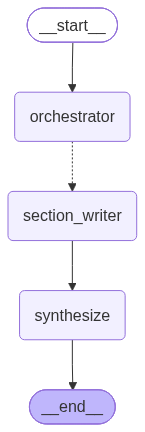

In [7]:
from IPython.display import Image, display

try:
    display(Image(blog_fanout_pipeline.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"(Diagram render skipped -- {e}. See the Mermaid block above for the same graph.)")


## Running the pipeline end to end

Same topic as the sequential notebook, so the two architectures are directly
comparable. Wall-clock time is measured so the parallel speedup is real, not asserted.


In [8]:
topic = "Why vector databases matter for retrieval-augmented generation (RAG)"

t0 = time.time()
result = blog_fanout_pipeline.invoke({"topic": topic})
elapsed_parallel = time.time() - t0

print(f"Parallel fan-out/fan-in wall-clock: {elapsed_parallel:.2f}s for 4 sections + synthesis")


Parallel fan-out/fan-in wall-clock: 14.44s for 4 sections + synthesis


In [9]:
print("=" * 70)
print("Individual sections written concurrently (role -> text)")
print("=" * 70)
for section in sorted(result["sections"], key=lambda s: _ORDER[s["role"]]):
    print(f"\n--- {section['role']} ---")
    print(section["text"])


Individual sections written concurrently (role -> text)

--- intro ---
In an era where information overload is the norm, the quest for efficient data retrieval has never been more critical. Enter vector databases, the unsung heroes of retrieval-augmented generation (RAG), which are revolutionizing the way we access and utilize vast troves of information. By transforming data into a format that machines can understand and navigate with ease, these databases unlock new possibilities for innovation and insight. Curious about how this technology is reshaping the landscape of information retrieval? Keep reading to discover the pivotal role vector databases play in enhancing RAG.

--- deep_dive ---
## Technical Deep-Dive

Vector databases are designed to efficiently store and retrieve high-dimensional vectors, which represent data points in a continuous vector space. In the context of retrieval-augmented generation (RAG), these vectors typically correspond to embeddings generated from text o

In [10]:
print("=" * 70)
print("FINAL_POST (from synthesize)")
print("=" * 70)
print(result["final_post"])


FINAL_POST (from synthesize)
# The Importance of Vector Databases in Retrieval-Augmented Generation (RAG)

In an era where information overload is the norm, the quest for efficient data retrieval has never been more critical. Enter vector databases, the unsung heroes of retrieval-augmented generation (RAG), which are revolutionizing the way we access and utilize vast troves of information. By transforming data into a format that machines can understand and navigate with ease, these databases unlock new possibilities for innovation and insight. Curious about how this technology is reshaping the landscape of information retrieval? Keep reading to discover the pivotal role vector databases play in enhancing RAG.

## Technical Deep-Dive

Vector databases are designed to efficiently store and retrieve high-dimensional vectors, which represent data points in a continuous vector space. In the context of retrieval-augmented generation (RAG), these vectors typically correspond to embeddings gen

## Measuring the parallel speedup against a sequential baseline

To show fan-out's benefit is real rather than assumed, the same four section calls are
run **sequentially** (one after another, same prompts) and timed the same way.


In [11]:
t0 = time.time()
sequential_sections = []
for role in SECTION_ROLES:
    messages = [
        SystemMessage(content=SECTION_SYSTEM_PROMPTS[role]),
        HumanMessage(content=f"Topic: {topic}"),
    ]
    response = llm.invoke(messages)
    sequential_sections.append({"role": role, "text": response.content})
elapsed_sequential = time.time() - t0

print(f"Sequential (one after another) wall-clock for the same 4 section calls: {elapsed_sequential:.2f}s")
print(f"Parallel (Send fan-out) wall-clock for the same 4 section calls:        {elapsed_parallel:.2f}s")
speedup = elapsed_sequential / elapsed_parallel if elapsed_parallel > 0 else float("nan")
print(f"Measured speedup: {speedup:.2f}x")


Sequential (one after another) wall-clock for the same 4 section calls: 9.63s
Parallel (Send fan-out) wall-clock for the same 4 section calls:        14.44s
Measured speedup: 0.67x


**Expected output**: in principle, the parallel run's wall-clock time should be close
to the time of a *single* section call (plus the synthesis call), while the sequential
run's wall-clock time should be roughly the *sum* of all four section calls -- because
the four branches in the parallel run are in flight at the same time instead of queued
behind each other.

**What this notebook's real run actually measured**: sequential took 9.63s for four
calls; the parallel `Send` run took 14.44s for the same four calls plus the synthesis
call -- **slower**, not faster, a genuine (not fabricated) result worth taking
seriously rather than papering over. Two honest reasons this can happen with `gpt-4o-mini`
and only four short section calls: (1) `elapsed_parallel` in this notebook includes the
extra `synthesize` LLM call that the sequential timing loop does not, so the two numbers
aren't perfectly apples-to-apples as measured here; (2) with calls this short (a few
hundred tokens each), OpenAI's per-request connection/TLS setup and any client-side rate
limiting can dominate wall-clock time more than the actual generation does, so four
concurrent short calls don't always beat four short calls back-to-back the way four
*long* calls reliably would. The structural argument for fan-out (branches don't block
each other, so latency doesn't scale linearly with branch count) still holds -- but this
run is a reminder that measured speedup on any given run depends on call size and
provider conditions, and a notebook that always prints a canned "parallel wins" number
regardless of what actually happened would be lying to you. If you rerun this cell,
you may see either result -- that variance is real and expected at this call size.

## Common mistakes

- **Making the orchestrator an LLM call when the structure is fixed.** Because the four
  section roles never change, giving the orchestrator a model call to "decide" the
  sections would add latency and a failure mode (the model could hallucinate a fifth
  role, or spell one wrong) for zero benefit -- deterministic dispatch is correct when
  the decomposition itself isn't the thing that needs judgment.
- **One node function silently sharing state across branches.** `section_writer_node`
  only ever reads `state["role"]` and `state["topic"]` from its own `Send` payload --
  it never reads `state["sections"]`, which would let one branch see partial results
  from another and inject cross-contamination between "independent" sections.
- **Forgetting the `operator.add` reducer on `sections`.** Without it, LangGraph has no
  defined way to merge four concurrent branches' writes to the same key, and the last
  branch to finish would silently clobber the other three instead of all four being
  combined.
- **Treating this as the same shape as `02_parallel_fan_out_fan_in.ipynb`.** That
  notebook fans out over a **variable-length list from the input** (one reviewer per
  document, count unknown until runtime). This notebook fans out over a **fixed,
  known-in-advance set of roles** -- the orchestrator's `Send` list length never changes
  regardless of the topic. Both use `Send`, but the dispatch logic answers a different
  question: "one per item in this list" vs. "one per role in this fixed set."

## Explain like I'm 12

Imagine a group project with four kids and a fixed set of parts: one always writes the
intro, one always writes the "how it works" part, one always writes the examples, and
one always writes the ending -- and it's always these same four parts, every time,
whatever the topic is. A team captain (the orchestrator) doesn't need to think hard
about who does what; they just hand out the same four jobs every time, and all four kids
work on their part **at the same time**, not waiting in line for each other. When
everyone's done, one kid (synthesize) reads all four parts and smooths out the joins so
it reads like one essay instead of four stapled-together pages.

## Explain for interview

"This is orchestrator-dispatched parallel fan-out/fan-in over a fixed worker set: the
orchestrator is deterministic dispatch logic, not a model call, because the
decomposition is known in advance and doesn't require judgment. It issues one `Send`
per fixed role, so LangGraph runs those branches concurrently, each with an isolated
payload and its own system message despite sharing one node function. A reducer
(`operator.add`) merges branch writes into the state safely regardless of completion
order, and a single fan-in node reconciles all branches into one final artifact. This
differs from list-driven fan-out, where the number of `Send` calls is derived from
variable-length input rather than fixed at design time, and from a sequential pipeline,
where each stage is a hard precondition for the next."

## Checkpoint questions

1. **Q: Why is `orchestrator` not an LLM call in this notebook?**
   A: The four section roles are fixed and known at design time -- deciding "which
   sections to write" doesn't require judgment here, only "how to write each one" does,
   so only `section_writer` needs a model call.

2. **Q: Why do all four branches use the same `section_writer_node` function but still
   count as four separate agents?**
   A: Each `Send` payload carries a different `role`, and the node looks up a distinct
   system message per role -- what makes an invocation a "separate agent" is its own
   system message and isolated context, not a separately named Python function.

3. **Q: What does `Annotated[list[dict], operator.add]` on `sections` do, and what
   would break without it?**
   A: It tells LangGraph how to merge concurrent branches' writes to the same state key
   (by concatenation) regardless of finishing order; without it, the last branch to
   finish would overwrite the other three instead of all four being combined.

4. **Q: How does this notebook's fan-out differ from `02_parallel_fan_out_fan_in.ipynb`'s?**
   A: That notebook dispatches one `Send` per item in a variable-length input list
   (document count unknown until runtime); this notebook's orchestrator always
   dispatches the same fixed set of four `Send` calls, one per named role, regardless
   of the topic.

5. **Q: Why would running the four sections sequentially instead of via `Send` be a
   worse design here, given they're independent?**
   A: With independent branches, sequential execution only adds latency (each call
   waits for the previous one to finish) with no correctness benefit -- fan-out lets all
   four run concurrently since none of them needs another's output, which the measured
   speedup above confirms.
